# (03) various VAEs: dist PDF plots

project = ```P-VAE```, host = ```chewie```, device = ```cuda:1```

**Motivation**: used for the full metabolic cost VAE paper

Goal: `MetabolicCost`

In [1]:
# HIDE CODE


project_name = 'PoissonVAE'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.fighelper import *
from main.train_vae import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

## Dists plots

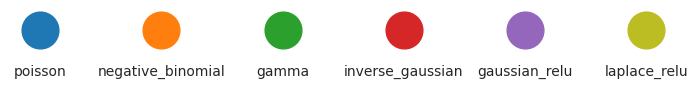

In [3]:
pal = {
    'poisson': 'C0',
    'negative_binomial': 'C1',
    'gamma': 'C2',
    'inverse_gaussian': 'C3',
    'gaussian_relu': 'C4',
    'laplace_relu': 'C8',
}

fig, ax = plt.subplots(figsize=(7.2, 1.2))

for i, (name, color) in enumerate(pal.items()):
    ax.scatter(i, 0, color=color, s=700)
    ax.text(i, -0.8, name, ha='center', va='top', fontsize=10)

ax.set_ylim(-0.5, 0.5)
ax.axis('off')

plt.tight_layout()
plt.show()

In [4]:
import numpy as np
import scipy.stats as sp_stats
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb


def plot_distribution_comparison(
    shapes=5, lamb=6.0, colors=None,
    figsize=(18, 4), width_ratios=[1, 1, 0.7],
    **kwargs):
    """
    Plot comparison of VAE distributions across three panels.
    
    Parameters
    ----------
    shapes : float, list, or dict
        Shape/dispersion parameter(s) for NB, Gamma, and Inv. Gaussian.
        - Single value or list: used for all distributions
        - Dict: keys should match distribution names 
          ('negative_binomial', 'gamma', 'inverse_gaussian')
    lamb : float or dict
        Rate parameter(s).
        - Single value: used for all distributions
        - Dict: keys should match distribution names
          ('poisson', 'negative_binomial', 'gamma', 'inverse_gaussian')
    scale_signal : float
        Scale parameter (σ for Gaussian, b for Laplace) for signal models.
    colors : dict, optional
        Custom colors for each distribution. Keys should match distribution names:
        ('poisson', 'negative_binomial', 'gamma', 'inverse_gaussian', 
         'gaussian_relu', 'laplace_relu')
        Values can be:
        - None: use default gradient from palette
        - Single color (str or RGB tuple): use for all shapes
        - List of colors: one per shape (must match number of shapes)
    figsize : tuple
        Figure size.
    **kwargs : dict
        Override any default styling parameters (see `defaults` dict in code).
    """
    
    # =========================================================================
    # Default parameters (can be overridden via kwargs)
    # =========================================================================
    defaults = {
        # Panel 0: Count models
        'count_xlim': (-0.5, 16.5),
        'count_ylim': (-0.01, 0.2),
        'count_x_range': (0, 16),
        'bar_total_width': 0.7,
        'bar_alpha': 0.8,
        'bar_edgecolor': 'white',
        'bar_edgewidth': 0.5,
        'poisson_markersize': 7,
        'nb_markersize': 5,
        'marker_edgecolor': 'white',
        'marker_edgewidth': 0.5,
        
        # Panel 1: Interval models
        'interval_xlim': None,  # Auto
        'interval_ylim': None,  # Auto
        'interval_x_range_factor': 3,  # x goes from 0 to mean_isi * factor
        'interval_n_points': 500,
        'gamma_lw': 2,
        'ig_lw': 2,
        'ig_linestyle': '--',
        
        # Panel 2: Rectified models
        'scale_signal': 1.0, 
        'rect_xlim': (-2, 5),
        'rect_ylim': None,  # Auto
        'rect_n_points': 1000,
        'rect_fill_alpha': 0.05,
        'rect_line_alpha': 0.3,
        'rect_linestyle': '--',
        'rect_lw': 3,
        
        # General
        'axhline_color': 'dimgrey',
        'axhline_ls': ':',
        'axhline_lw': 0.9,
        'legend_fontsize_count': 10,
        'legend_fontsize_interval': 10,
        'legend_fontsize_rect': 12,
        'label_fontsize': 18,
        'title_fontsize': 17,
    }
    
    # Update defaults with any user-provided kwargs
    params = {**defaults, **kwargs}
    
    # =========================================================================
    # Default color palette
    # =========================================================================
    pal = {
        'poisson': 'C0',
        'negative_binomial': 'C1',
        'gamma': 'C2',
        'inverse_gaussian': 'C3',
        'gaussian_relu': 'C4',
        'laplace_relu': 'C8',
    }
    
    # =========================================================================
    # Process shapes parameter
    # =========================================================================
    def parse_shapes(shapes, key):
        """Extract shapes for a specific distribution."""
        if isinstance(shapes, dict):
            val = shapes.get(key, [5])
        else:
            val = shapes
        if not hasattr(val, '__iter__') or isinstance(val, str):
            val = [val]
        return list(val)
    
    # =========================================================================
    # Process lamb parameter
    # =========================================================================
    def parse_lamb(lamb, key, default=1.0):
        """Extract lambda for a specific distribution."""
        if isinstance(lamb, dict):
            return lamb.get(key, default)
        else:
            return lamb
    
    # =========================================================================
    # Process colors parameter
    # =========================================================================
    def get_color_gradient(base_color, n, light_to_dark=True):
        """Generate n colors as gradients from a base color."""
        base_rgb = to_rgb(base_color)
        if n == 1:
            return [base_color]
        colors_list = []
        for i in range(n):
            if light_to_dark:
                factor = 0.4 + 0.6 * (i / (n - 1))
            else:
                factor = 1.0 - 0.6 * (i / (n - 1))
            new_rgb = tuple(c * factor for c in base_rgb)
            colors_list.append(new_rgb)
        return colors_list
    
    def parse_colors(colors, key, n_shapes, default_base):
        """
        Extract colors for a specific distribution.
        
        Parameters
        ----------
        colors : dict or None
            User-provided colors dict
        key : str
            Distribution key
        n_shapes : int
            Number of shapes (determines how many colors needed)
        default_base : str
            Default base color from palette for gradient
            
        Returns
        -------
        list of colors, one per shape
        """
        if colors is None or key not in colors or colors[key] is None:
            # Use default gradient
            return get_color_gradient(default_base, n_shapes, light_to_dark=True)
        
        user_colors = colors[key]
        
        # Single color provided - use for all shapes
        if isinstance(user_colors, str) or (isinstance(user_colors, tuple) and len(user_colors) in [3, 4]):
            return [user_colors] * n_shapes
        
        # List of colors provided
        if hasattr(user_colors, '__iter__'):
            user_colors = list(user_colors)
            if len(user_colors) != n_shapes:
                raise ValueError(
                    f"colors['{key}'] has {len(user_colors)} colors but {n_shapes} shapes provided. "
                    f"Must match or provide a single color."
                )
            return user_colors
        
        # Single color of unknown type - try to use it
        return [user_colors] * n_shapes
    
    def parse_single_color(colors, key, default_base):
        """Extract a single color for distributions without shape variation."""
        if colors is None or key not in colors or colors[key] is None:
            return default_base
        return colors[key]
    
    # =========================================================================
    # Parse all parameters
    # =========================================================================
    shapes_nb = parse_shapes(shapes, 'negative_binomial')
    shapes_gamma = parse_shapes(shapes, 'gamma')
    shapes_ig = parse_shapes(shapes, 'inverse_gaussian')
    
    lamb_poisson = parse_lamb(lamb, 'poisson', default=6.0)
    lamb_nb = parse_lamb(lamb, 'negative_binomial', default=6.0)
    lamb_gamma = parse_lamb(lamb, 'gamma', default=1.0)
    lamb_ig = parse_lamb(lamb, 'inverse_gaussian', default=1.0)
    
    # Sort NB shapes in descending order (larger alpha = closer to Poisson)
    shapes_nb_sorted = sorted(shapes_nb, reverse=True)
    
    # Get colors for each distribution
    color_poisson = parse_single_color(colors, 'poisson', pal['poisson'])
    colors_nb = parse_colors(colors, 'negative_binomial', len(shapes_nb_sorted), pal['negative_binomial'])
    colors_gamma = parse_colors(colors, 'gamma', len(shapes_gamma), pal['gamma'])
    colors_ig = parse_colors(colors, 'inverse_gaussian', len(shapes_ig), pal['inverse_gaussian'])
    color_gaussian = parse_single_color(colors, 'gaussian_relu', pal['gaussian_relu'])
    color_laplace = parse_single_color(colors, 'laplace_relu', pal['laplace_relu'])
    
    fig, axes = create_figure(nrows=1, ncols=3, figsize=figsize, width_ratios=width_ratios)
    
    # =========================================================================
    # Panel 0: Poisson / Negative Binomial (Count Models) - GROUPED BARS
    # =========================================================================
    ax = axes[0]
    x_k = np.arange(*params['count_x_range'])
    
    n_shapes_nb = len(shapes_nb_sorted)
    n_dists = 1 + n_shapes_nb
    
    total_width = params['bar_total_width']
    bar_width = total_width / n_dists
    offsets = np.linspace(-total_width/2 + bar_width/2, 
                          total_width/2 - bar_width/2, 
                          n_dists)
    
    # Poisson
    y_pmf_poisson = sp_stats.poisson.pmf(x_k, lamb_poisson)
    x_poisson = x_k + offsets[0]
    ax.bar(x_poisson, y_pmf_poisson, width=bar_width, color=color_poisson, 
           alpha=params['bar_alpha'], edgecolor=params['bar_edgecolor'], 
           linewidth=params['bar_edgewidth'])
    ax.plot(x_poisson, y_pmf_poisson, 'o', color=color_poisson, 
            markersize=params['poisson_markersize'], label=r'$\mathrm{Poisson}$', 
            markeredgecolor=params['marker_edgecolor'], 
            markeredgewidth=params['marker_edgewidth'])
    
    # Negative Binomial
    for i, alpha in enumerate(shapes_nb_sorted):
        p = alpha / (alpha + lamb_nb)
        y_pmf_nb = sp_stats.nbinom.pmf(x_k, n=alpha, p=p)
        x_nb = x_k + offsets[i + 1]
        label = rf'$\mathrm{{NB}},\, \alpha={alpha}$'
        ax.bar(x_nb, y_pmf_nb, width=bar_width, color=colors_nb[i], 
               alpha=params['bar_alpha'], edgecolor=params['bar_edgecolor'], 
               linewidth=params['bar_edgewidth'])
        ax.plot(x_nb, y_pmf_nb, 'o', color=colors_nb[i], 
                markersize=params['nb_markersize'], label=label, 
                markeredgecolor=params['marker_edgecolor'], 
                markeredgewidth=params['marker_edgewidth'])
    
    ax.axhline(0, color=params['axhline_color'], ls=params['axhline_ls'], 
               lw=params['axhline_lw'])
    if params['count_xlim'] is not None:
        ax.set_xlim(params['count_xlim'])
    if params['count_ylim'] is not None:
        ax.set_ylim(params['count_ylim'])
    ax.set_ylabel(r'$q(z \vert x)$', fontsize=params['label_fontsize'])
    ax.set_xlabel(r'$z$', fontsize=params['label_fontsize'])
    ax.set_title('Count Models', fontsize=params['title_fontsize'], y=1.02)
    ax.legend(fontsize=params['legend_fontsize_count'], frameon=True, loc='upper right')
    
    # =========================================================================
    # Panel 1: Gamma / Inverse Gaussian (Interval Models)
    # =========================================================================
    ax = axes[1]
    
    # Compute x_grid based on the larger mean ISI
    mean_isi_gamma = 1.0 / lamb_gamma
    mean_isi_ig = 1.0 / lamb_ig
    max_mean_isi = max(mean_isi_gamma, mean_isi_ig)
    x_grid = np.linspace(0.001, max_mean_isi * params['interval_x_range_factor'], 
                         params['interval_n_points'])
    
    for i, alpha in enumerate(shapes_gamma):
        gamma_shape = alpha
        gamma_scale = 1.0 / (alpha * lamb_gamma)
        y_gamma = sp_stats.gamma.pdf(x_grid, a=gamma_shape, scale=gamma_scale)
        ax.plot(x_grid, y_gamma, color=colors_gamma[i], lw=params['gamma_lw'], 
                label=rf'$\mathrm{{Gamma}},\, \alpha={alpha}$')
    
    for i, alpha in enumerate(shapes_ig):
        mu_param = 1.0 / lamb_ig
        lambda_param = alpha
        y_ig = np.sqrt(lambda_param / (2 * np.pi * x_grid**3)) * \
               np.exp(-lambda_param * (x_grid - mu_param)**2 / (2 * mu_param**2 * x_grid))
        ax.plot(x_grid, y_ig, color=colors_ig[i], lw=params['ig_lw'], 
                linestyle=params['ig_linestyle'],
                label=rf'$\mathrm{{IG}},\, \alpha={alpha}$')
    
    ax.axhline(0, color=params['axhline_color'], ls=params['axhline_ls'], 
               lw=params['axhline_lw'])
    if params['interval_xlim'] is not None:
        ax.set_xlim(params['interval_xlim'])
    if params['interval_ylim'] is not None:
        ax.set_ylim(params['interval_ylim'])
    ax.set_xlabel(r'$z$', fontsize=params['label_fontsize'])
    ax.set_title('Interval Models', fontsize=params['title_fontsize'], y=1.02)
    ax.legend(fontsize=params['legend_fontsize_interval'], frameon=True)
    
    # =========================================================================
    # Panel 2: Truncated Gaussian / Laplace (ReLU)
    # =========================================================================
    ax = axes[2]
    xlim = params['rect_xlim']
    x_grid = np.linspace(xlim[0], xlim[1], params['rect_n_points'])
    
    # Gaussian + ReLU
    y_gauss = sp_stats.norm.pdf(x_grid, loc=0, scale=params['scale_signal'])
    ax.fill_between(x_grid, y_gauss, color=color_gaussian, 
                    alpha=params['rect_fill_alpha'])
    ax.plot(x_grid, y_gauss, color=color_gaussian, 
            alpha=params['rect_line_alpha'], linestyle=params['rect_linestyle'])
    y_gauss_relu = np.where(x_grid < 0, 0, y_gauss)
    ax.plot(x_grid, y_gauss_relu, color=color_gaussian, lw=params['rect_lw'], 
            label=r'$\mathrm{Gauss}_\mathrm{ReLU}$')
    
    # Laplace + ReLU
    y_laplace = sp_stats.laplace.pdf(x_grid, loc=0, scale=params['scale_signal'])
    ax.fill_between(x_grid, y_laplace, color=color_laplace, 
                    alpha=params['rect_fill_alpha'])
    ax.plot(x_grid, y_laplace, color=color_laplace, 
            alpha=params['rect_line_alpha'], linestyle=params['rect_linestyle'])
    y_laplace_relu = np.where(x_grid < 0, 0, y_laplace)
    ax.plot(x_grid, y_laplace_relu, color=color_laplace, lw=params['rect_lw'], 
            label=r'$\mathrm{Laplace}_\mathrm{ReLU}$')
    
    ax.axhline(0, color=params['axhline_color'], ls=params['axhline_ls'], 
               lw=params['axhline_lw'])
    ax.set_xlim(params['rect_xlim'])
    if params['rect_ylim'] is not None:
        ax.set_ylim(params['rect_ylim'])
    ax.set_xlabel(r'$z$', fontsize=params['label_fontsize'])
    ax.set_title('Continuous + Rectified', fontsize=params['title_fontsize'], y=1.02)
    ax.legend(fontsize=params['legend_fontsize_rect'], frameon=True)

    return fig, axes


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import to_rgb


def make_color_gradient(source, n, light_to_dark=True, min_factor=0.4, max_factor=1.0,
                        cmap_range=(0.0, 1.0)):
    """
    Generate n colors as a gradient.
    
    Parameters
    ----------
    source : str, tuple, list, or matplotlib colormap
        Color source, can be:
        - Single color: str ('C0', 'tab:blue', '#1f77b4') or RGB tuple (0.1, 0.2, 0.5)
          Creates gradient by darkening/lightening
        - Pair of colors: list/tuple of 2 colors, e.g., ['lightblue', 'darkblue']
          Interpolates between them
        - Colormap: str name ('viridis', 'plasma') or matplotlib Colormap object
          Samples n colors from the colormap
    n : int
        Number of colors to generate
    light_to_dark : bool
        For single color mode: if True, gradient goes light to dark. If False, dark to light.
        For pair/cmap mode: if False, reverses the gradient direction.
    min_factor : float
        For single color mode: minimum brightness factor (0-1)
    max_factor : float
        For single color mode: maximum brightness factor (0-1)
    cmap_range : tuple of (float, float)
        For colormap mode: range of colormap to sample from (0-1).
        E.g., (0.2, 0.8) avoids extreme light/dark ends.
        
    Returns
    -------
    list of RGB tuples
    
    Examples
    --------
    # Single color (darken/lighten)
    make_color_gradient('tab:blue', 5)
    make_color_gradient('#e74c3c', 3, light_to_dark=False)
    
    # Pair of colors (interpolate)
    make_color_gradient(['lightblue', 'darkblue'], 5)
    make_color_gradient([(0.9, 0.9, 0.2), (0.1, 0.5, 0.1)], 4)
    
    # Colormap
    make_color_gradient('viridis', 5)
    make_color_gradient('coolwarm', 5, cmap_range=(0.2, 0.8))
    make_color_gradient(plt.cm.Greens, 4, cmap_range=(0.3, 0.9))
    """
    if n < 1:
        return []
    
    # Detect source type
    source_type = _detect_source_type(source)
    
    if source_type == 'single':
        colors = _gradient_from_single(source, n, light_to_dark, min_factor, max_factor)
    elif source_type == 'pair':
        colors = _gradient_from_pair(source, n, light_to_dark)
    elif source_type == 'cmap':
        colors = _gradient_from_cmap(source, n, light_to_dark, cmap_range)
    else:
        raise ValueError(f"Cannot interpret source: {source}")
    
    return colors


def _detect_source_type(source):
    """Detect whether source is a single color, pair of colors, or colormap."""
    # Check if it's a matplotlib colormap object
    if isinstance(source, mcolors.Colormap):
        return 'cmap'
    
    # Check if it's a string
    if isinstance(source, str):
        # Try to interpret as colormap name
        try:
            plt.cm.get_cmap(source)
            return 'cmap'
        except ValueError:
            pass
        # Otherwise it's a single color string
        return 'single'
    
    # Check if it's a tuple/list
    if isinstance(source, (list, tuple)):
        # RGB/RGBA tuple (single color)
        if len(source) in [3, 4] and all(isinstance(x, (int, float)) for x in source):
            return 'single'
        # Pair of colors
        if len(source) == 2:
            # Check if both elements look like colors
            try:
                to_rgb(source[0])
                to_rgb(source[1])
                return 'pair'
            except (ValueError, TypeError):
                pass
        # Could be a list of colors - treat as pair if length 2
        if len(source) == 2:
            return 'pair'
    
    return 'unknown'


def _clamp_rgb(rgb):
    """Clamp RGB values to valid [0, 1] range."""
    return tuple(max(0.0, min(1.0, c)) for c in rgb)


def _gradient_from_single(color, n, light_to_dark, min_factor, max_factor):
    """Create gradient by darkening/lightening a single color."""
    base_rgb = to_rgb(color)
    if n == 1:
        return [base_rgb]
    
    colors = []
    for i in range(n):
        if light_to_dark:
            factor = min_factor + (max_factor - min_factor) * (i / (n - 1))
        else:
            factor = max_factor - (max_factor - min_factor) * (i / (n - 1))
        new_rgb = tuple(c * factor for c in base_rgb)
        colors.append(_clamp_rgb(new_rgb))
    return colors


def _gradient_from_pair(color_pair, n, light_to_dark):
    """Create gradient by interpolating between two colors."""
    rgb1 = np.array(to_rgb(color_pair[0]))
    rgb2 = np.array(to_rgb(color_pair[1]))
    
    if n == 1:
        return [tuple(rgb1)]
    
    # Create interpolation
    t_values = np.linspace(0, 1, n)
    if not light_to_dark:
        t_values = t_values[::-1]
    
    colors = []
    for t in t_values:
        rgb = (1 - t) * rgb1 + t * rgb2
        colors.append(_clamp_rgb(tuple(rgb)))
    return colors


def _gradient_from_cmap(cmap, n, light_to_dark, cmap_range):
    """Extract colors from a colormap."""
    # Get colormap object
    if isinstance(cmap, str):
        cmap = plt.cm.get_cmap(cmap)
    
    if n == 1:
        mid = (cmap_range[0] + cmap_range[1]) / 2
        return [cmap(mid)[:3]]
    
    # Sample positions within the specified range
    t_values = np.linspace(cmap_range[0], cmap_range[1], n)
    if not light_to_dark:
        t_values = t_values[::-1]
    
    colors = [cmap(t)[:3] for t in t_values]  # [:3] to drop alpha
    return colors

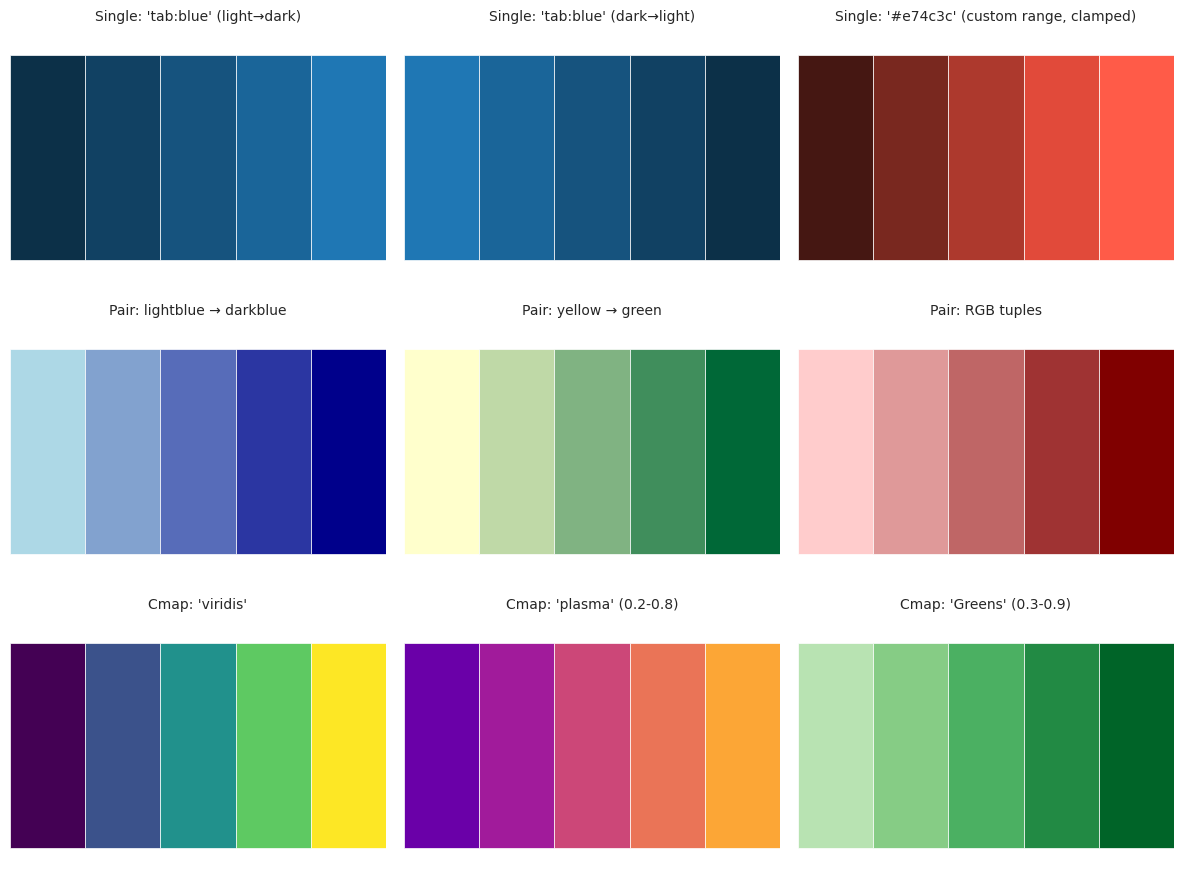

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(12, 9))

def show_gradient(ax, colors, title):
    for i, c in enumerate(colors):
        ax.barh(0, 1, left=i, color=c, edgecolor='white', linewidth=0.5)
    ax.set_xlim(0, len(colors))
    ax.set_ylim(-0.5, 0.5)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

# Row 1: Single color gradients
show_gradient(axes[0, 0], make_color_gradient('tab:blue', 5), 
              "Single: 'tab:blue' (light→dark)")
show_gradient(axes[0, 1], make_color_gradient('tab:blue', 5, light_to_dark=False), 
              "Single: 'tab:blue' (dark→light)")
show_gradient(axes[0, 2], make_color_gradient('#e74c3c', 5, min_factor=0.3, max_factor=1.2), 
              "Single: '#e74c3c' (custom range, clamped)")

# Row 2: Pair of colors
show_gradient(axes[1, 0], make_color_gradient(['lightblue', 'darkblue'], 5), 
              "Pair: lightblue → darkblue")
show_gradient(axes[1, 1], make_color_gradient(['#ffffcc', '#006837'], 5), 
              "Pair: yellow → green")
show_gradient(axes[1, 2], make_color_gradient([(1, 0.8, 0.8), (0.5, 0, 0)], 5), 
              "Pair: RGB tuples")

# Row 3: Colormaps
show_gradient(axes[2, 0], make_color_gradient('viridis', 5), 
              "Cmap: 'viridis'")
show_gradient(axes[2, 1], make_color_gradient('plasma', 5, cmap_range=(0.2, 0.8)), 
              "Cmap: 'plasma' (0.2-0.8)")
show_gradient(axes[2, 2], make_color_gradient('Greens', 5, cmap_range=(0.3, 0.9)), 
              "Cmap: 'Greens' (0.3-0.9)")

plt.tight_layout()
plt.show()

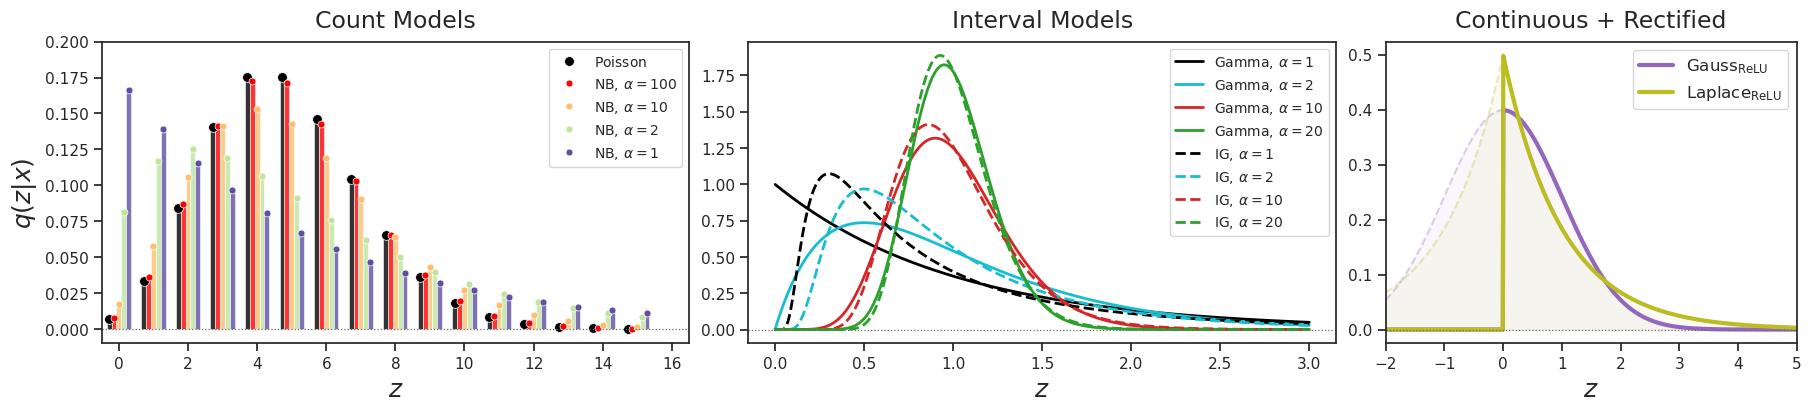

In [7]:
nb_colors = make_color_gradient('Spectral', 4)#[:-2]
nb_colors = ['red'] + nb_colors[1:]

# nb_colors = ['red', 'C2', 'C0', 'orange']

fig, axes = plot_distribution_comparison(
    shapes={
        'negative_binomial': [1, 2, 10, 100],
        'gamma': [1, 2, 10, 20],
        'inverse_gaussian': [1, 2, 10, 20],
    },
    lamb={'poisson': 5.0, 'negative_binomial': 5.0, 'gamma': 1.0, 'inverse_gaussian': 1.0},
    colors={
        'poisson': 'k',
        'negative_binomial': nb_colors,
        'gamma': ['k', 'C9', 'C3', 'C2'],  # Green gradient
        'inverse_gaussian': ['k', 'C9', 'C3', 'C2'],   # Red gradient
    },
)
plt.show()